In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris, load_diabetes
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.neighbors import KNeighborsClassifier
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import MinMaxScaler

In [2]:
url = "https://archive.ics.uci.edu/static/public/186/data.csv"
df_calidad_vino = pd.read_csv(url)
df_calidad_vino.head()
df_calidad_vino_white = df_calidad_vino[df_calidad_vino["color"] == "white"]
df_calidad_vino_red = df_calidad_vino[df_calidad_vino["color"] == "red"]
df_calidad_vino_white = df_calidad_vino_white.drop(columns=["color"])
df_calidad_vino_red = df_calidad_vino_red.drop(columns=["color"])

In [3]:
df_calidad_vino.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed_acidity         6497 non-null   float64
 1   volatile_acidity      6497 non-null   float64
 2   citric_acid           6497 non-null   float64
 3   residual_sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free_sulfur_dioxide   6497 non-null   float64
 6   total_sulfur_dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  color                 6497 non-null   object 
dtypes: float64(11), int64(1), object(1)
memory usage: 660.0+ KB


In [4]:
df_calidad_vino['quality'].value_counts().sort_index()

quality
3      30
4     216
5    2138
6    2836
7    1079
8     193
9       5
Name: count, dtype: int64

In [5]:
df_calidad_vino['color'] = df_calidad_vino['color'].map({'red': 0, 'white': 1})

In [6]:
#Regresión Logística
q_33 = df_calidad_vino['quality'].quantile(0.33)
q_66 = df_calidad_vino['quality'].quantile(0.66)
def calidad(puntuacion):
    if puntuacion <= q_33:
        return 'Baja'
    elif puntuacion > q_66:
        return 'Alta'
    else:
        return 'Media'

df_calidad_vino['quality'] = df_calidad_vino['quality'].apply(calidad)
X = df_calidad_vino.drop('quality', axis=1)
y = df_calidad_vino['quality']

In [7]:
df_calidad_vino['quality'].value_counts().sort_index()

quality
Alta     1277
Baja     2384
Media    2836
Name: count, dtype: int64

In [8]:
np.random.seed(1917)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=1917)

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)


X_test_scaled = scaler.transform(X_test)

print(f"Tamaño del conjunto de entrenamiento escalado: {X_train_scaled.shape}")
print(f"Tamaño del conjunto de prueba escalado: {X_test_scaled.shape}")

Tamaño del conjunto de entrenamiento escalado: (5197, 12)
Tamaño del conjunto de prueba escalado: (1300, 12)


In [9]:
model = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=5000)
model.fit(X_train_scaled, y_train)

C:\Users\M.A.R\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(max_iter=5000, multi_class='multinomial')

In [10]:
coef_df = pd.DataFrame(model.coef_, columns=X.columns, index=model.classes_)

In [11]:
print("--- Interpretación de Coeficientes ---")
display(coef_df)

--- Interpretación de Coeficientes ---


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,color
Alta,1.358803,-3.670136,-0.231513,2.212353,-1.515957,1.760933,-1.088825,-2.099574,1.275034,2.163708,3.956063,-0.077323
Baja,-0.736513,4.841820,0.454521,-2.095419,0.963521,-2.467874,1.556302,1.420885,-0.767460,-2.177534,-4.394315,0.235231
Media,-0.622290,-1.171684,-0.223008,-0.116934,0.552436,0.706941,-0.467477,0.678689,-0.507574,0.013826,0.438252,-0.157907



--- Métricas de Desempeño ---
              precision    recall  f1-score   support

        Alta       0.60      0.32      0.42       258
        Baja       0.65      0.64      0.65       480
       Media       0.54      0.67      0.60       562

    accuracy                           0.59      1300
   macro avg       0.60      0.54      0.55      1300
weighted avg       0.59      0.59      0.58      1300



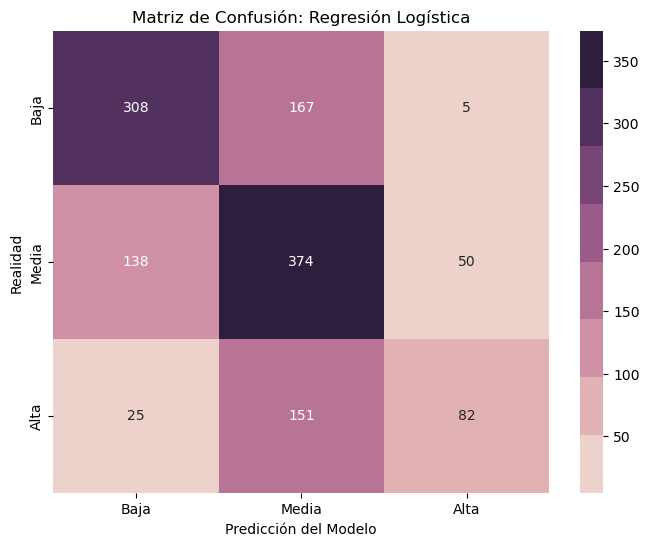

In [12]:

y_pred = model.predict(X_test_scaled)

print("\n--- Métricas de Desempeño ---")
print(classification_report(y_test, y_pred))

plt.figure(figsize=(8, 6))

labels = ['Baja', 'Media', 'Alta']
cm = confusion_matrix(y_test, y_pred, labels=labels)
default_cube = sns.cubehelix_palette(8)
sns.heatmap(cm, annot=True, fmt='d', cmap=default_cube,
            xticklabels=labels, yticklabels=labels)
plt.title("Matriz de Confusión: Regresión Logística")
plt.ylabel('Realidad')
plt.xlabel('Predicción del Modelo')
plt.show()

In [13]:
report_dict = classification_report(
    y_test,
    y_pred,
    output_dict=True 
)

df_report = pd.DataFrame(report_dict).transpose()

nombre_archivo = "metricas_log.xlsx"
df_report.to_excel(nombre_archivo, index=True)

In [14]:
#KNN sobre el conjunto total
error_rates = []

for i in range(1, 72):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train_scaled, y_train)
    y_pred_i = knn.predict(X_test_scaled)
    error = 1 - accuracy_score(y_test, y_pred_i)
    error_rates.append(error)

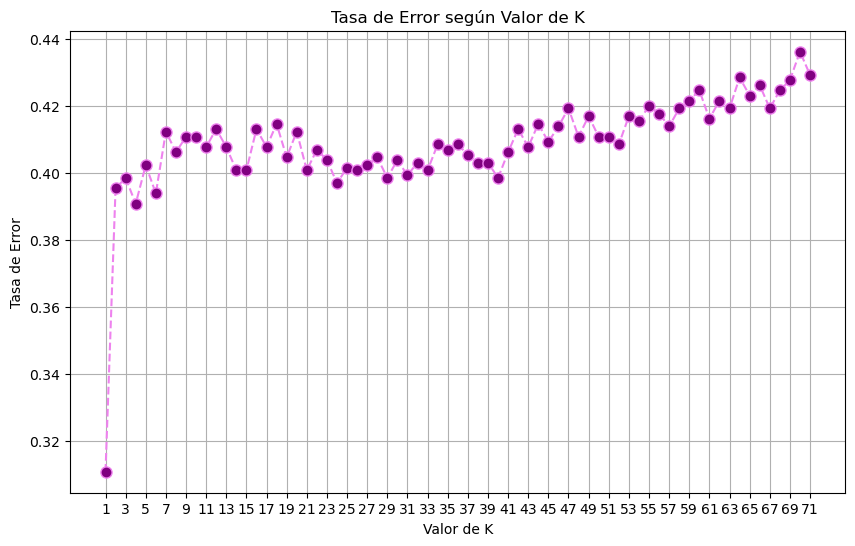

In [15]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, 72), error_rates, color='violet', linestyle='dashed', marker='o',
         markerfacecolor='purple', markersize=8)
plt.title('Tasa de Error según Valor de K')
plt.xlabel('Valor de K')
plt.ylabel('Tasa de Error')
plt.xticks(np.arange(1, 72, 2))
plt.grid(True)
plt.show()

In [16]:
optimal_k_index = np.argmin(error_rates)
optimal_k = range(1, 100)[optimal_k_index]
min_error = error_rates[optimal_k_index]

print(f"\nEl valor de K con la tasa de error más baja ({min_error:.4f}) es: {optimal_k}")

knn_optimal = KNeighborsClassifier(n_neighbors=optimal_k)
knn_optimal.fit(X_train_scaled, y_train)
y_pred_optimal = knn_optimal.predict(X_test_scaled)

print(f"\n--- Evaluación Final para K Óptimo = {optimal_k} ---")
print("Reporte de Clasificación Final:\n")
print(classification_report(y_test, y_pred_optimal))
report_dict = classification_report(
    y_test,
    y_pred_optimal,
    output_dict=True 
)

df_report = pd.DataFrame(report_dict).transpose()

nombre_archivo = "metricas_knn.xlsx"
df_report.to_excel(nombre_archivo, index=True)


El valor de K con la tasa de error más baja (0.3108) es: 1

--- Evaluación Final para K Óptimo = 1 ---
Reporte de Clasificación Final:

              precision    recall  f1-score   support

        Alta       0.67      0.70      0.69       258
        Baja       0.73      0.71      0.72       480
       Media       0.66      0.67      0.67       562

    accuracy                           0.69      1300
   macro avg       0.69      0.69      0.69      1300
weighted avg       0.69      0.69      0.69      1300



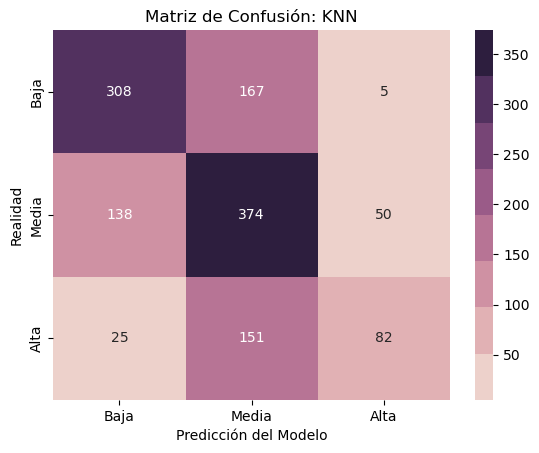


Clase 0:
 TP: 308
 TN: 657
 FP: 163
 FN: 172

Clase 1:
 TP: 374
 TN: 420
 FP: 318
 FN: 188

Clase 2:
 TP: 82
 TN: 987
 FP: 55
 FN: 176


In [17]:
labels = ['Baja', 'Media', 'Alta']
cm = confusion_matrix(y_test, y_pred, labels=labels)
default_cube = sns.cubehelix_palette(8)
sns.heatmap(cm, annot=True, fmt='d', cmap=default_cube,
            xticklabels=labels, yticklabels=labels)
plt.title("Matriz de Confusión: KNN")
plt.ylabel('Realidad')
plt.xlabel('Predicción del Modelo')
plt.show()
classes = cm.shape[0]

tp = np.diag(cm)
fp = cm.sum(axis=0) - tp
fn = cm.sum(axis=1) - tp
tn = cm.sum() - (tp + fp + fn)

for i in range(classes):
    print(f"\nClase {i}:")
    print(" TP:", tp[i])
    print(" TN:", tn[i])
    print(" FP:", fp[i])
    print(" FN:", fn[i])

In [18]:
#KNN (white wines)
p33 = np.percentile(df_calidad_vino_white['quality'], 33)
p66 = np.percentile(df_calidad_vino_white['quality'], 66)
def calidad(x):
    if x >= p66:
        return "Alta"
    elif x >= p33:
        return "Media"
    else:
        return "Baja"

In [19]:
df_calidad_vino_white['quality'] = df_calidad_vino_white['quality'].apply(calidad)

In [20]:
df_calidad_vino_white['quality'].value_counts().sort_index()

quality
Alta     3258
Baja      183
Media    1457
Name: count, dtype: int64

In [21]:
X = df_calidad_vino_white.drop('quality', axis=1)
y = df_calidad_vino_white['quality']

In [22]:
np.random.seed(1917)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=1917)

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)


X_test_scaled = scaler.transform(X_test)

print(f"Tamaño del conjunto de entrenamiento escalado: {X_train_scaled.shape}")
print(f"Tamaño del conjunto de prueba escalado: {X_test_scaled.shape}")

Tamaño del conjunto de entrenamiento escalado: (3918, 11)
Tamaño del conjunto de prueba escalado: (980, 11)


In [23]:
error_rates = []

for i in range(1, 72):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train_scaled, y_train)
    y_pred_i = knn.predict(X_test_scaled)
    error = 1 - accuracy_score(y_test, y_pred_i)
    error_rates.append(error)

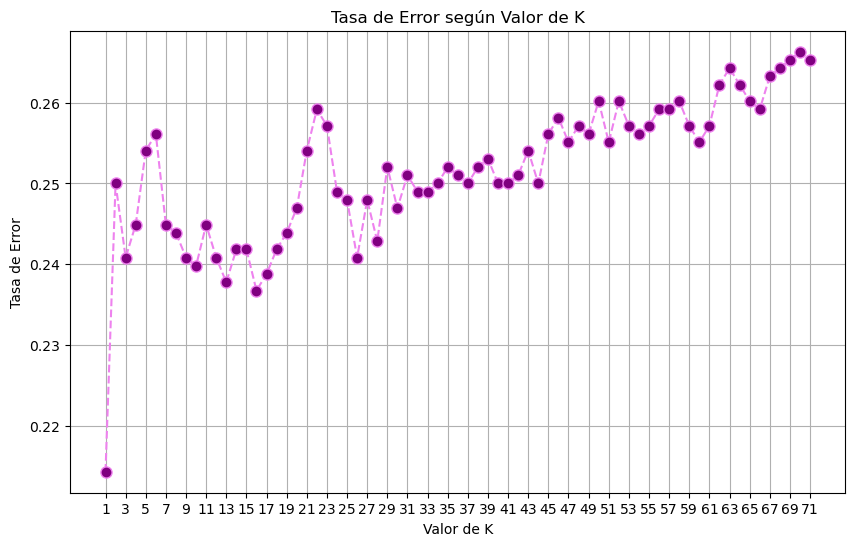

In [24]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, 72), error_rates, color='violet', linestyle='dashed', marker='o',
         markerfacecolor='purple', markersize=8)
plt.title('Tasa de Error según Valor de K')
plt.xlabel('Valor de K')
plt.ylabel('Tasa de Error')
plt.xticks(np.arange(1, 72, 2))
plt.grid(True)
plt.show()

In [25]:
optimal_k_index = np.argmin(error_rates)
optimal_k = range(1, 72)[optimal_k_index]
min_error = error_rates[optimal_k_index]

print(f"\nEl valor de K con la tasa de error más baja ({min_error:.4f}) es: {optimal_k}")

knn_optimal = KNeighborsClassifier(n_neighbors=optimal_k)
knn_optimal.fit(X_train_scaled, y_train)
y_pred_optimal = knn_optimal.predict(X_test_scaled)

print(f"\n--- Evaluación Final para K Óptimo = {optimal_k} ---")
print("Reporte de Clasificación Final KNN (vinos blancos):\n")
print(classification_report(y_test, y_pred_optimal))
report_dict = classification_report(
    y_test,
    y_pred_optimal,
    output_dict=True 
)

df_report = pd.DataFrame(report_dict).transpose()

nombre_archivo = "metricas_knn_vinos_blanco.xlsx"
df_report.to_excel(nombre_archivo, index=True)


El valor de K con la tasa de error más baja (0.2143) es: 1

--- Evaluación Final para K Óptimo = 1 ---
Reporte de Clasificación Final KNN (vinos blancos):

              precision    recall  f1-score   support

        Alta       0.83      0.88      0.86       652
        Baja       0.42      0.24      0.31        45
       Media       0.70      0.66      0.68       283

    accuracy                           0.79       980
   macro avg       0.65      0.59      0.61       980
weighted avg       0.78      0.79      0.78       980



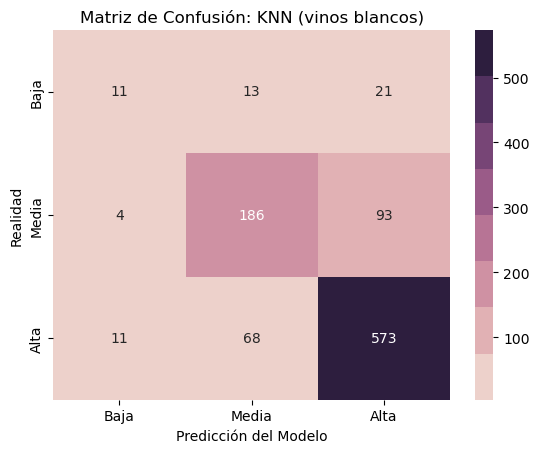


Clase 0:
 TP: 11
 TN: 920
 FP: 15
 FN: 34

Clase 1:
 TP: 186
 TN: 616
 FP: 81
 FN: 97

Clase 2:
 TP: 573
 TN: 214
 FP: 114
 FN: 79


In [26]:
labels = ['Baja', 'Media', 'Alta']
cm = confusion_matrix(y_test, y_pred_optimal, labels=labels)
default_cube = sns.cubehelix_palette(8)
sns.heatmap(cm, annot=True, fmt='d', cmap=default_cube,
            xticklabels=labels, yticklabels=labels)
plt.title("Matriz de Confusión: KNN (vinos blancos)")
plt.ylabel('Realidad')
plt.xlabel('Predicción del Modelo')
plt.show()
classes = cm.shape[0]

tp = np.diag(cm)
fp = cm.sum(axis=0) - tp
fn = cm.sum(axis=1) - tp
tn = cm.sum() - (tp + fp + fn)

for i in range(classes):
    print(f"\nClase {i}:")
    print(" TP:", tp[i])
    print(" TN:", tn[i])
    print(" FP:", fp[i])
    print(" FN:", fn[i])

In [27]:
p33 = np.percentile(df_calidad_vino_red['quality'], 33)
p66 = np.percentile(df_calidad_vino_red['quality'], 66)
def calidad(x):
    if x >= 7:
        return "Alta"
    elif x == 6:
        return "Media"
    else:
        return "Baja"

In [28]:
df_calidad_vino_red['quality'] = df_calidad_vino_red['quality'].apply(calidad)

In [29]:
df_calidad_vino_red['quality'].value_counts().sort_index()

quality
Alta     217
Baja     744
Media    638
Name: count, dtype: int64

In [30]:
X = df_calidad_vino_red.drop('quality', axis=1)
y = df_calidad_vino_red['quality']

In [31]:
np.random.seed(1917)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=1917)

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)


X_test_scaled = scaler.transform(X_test)

print(f"Tamaño del conjunto de entrenamiento escalado: {X_train_scaled.shape}")
print(f"Tamaño del conjunto de prueba escalado: {X_test_scaled.shape}")

Tamaño del conjunto de entrenamiento escalado: (1279, 11)
Tamaño del conjunto de prueba escalado: (320, 11)


In [32]:
error_rates = []

for i in range(1, 72):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train_scaled, y_train)
    y_pred_i = knn.predict(X_test_scaled)
    error = 1 - accuracy_score(y_test, y_pred_i)
    error_rates.append(error)

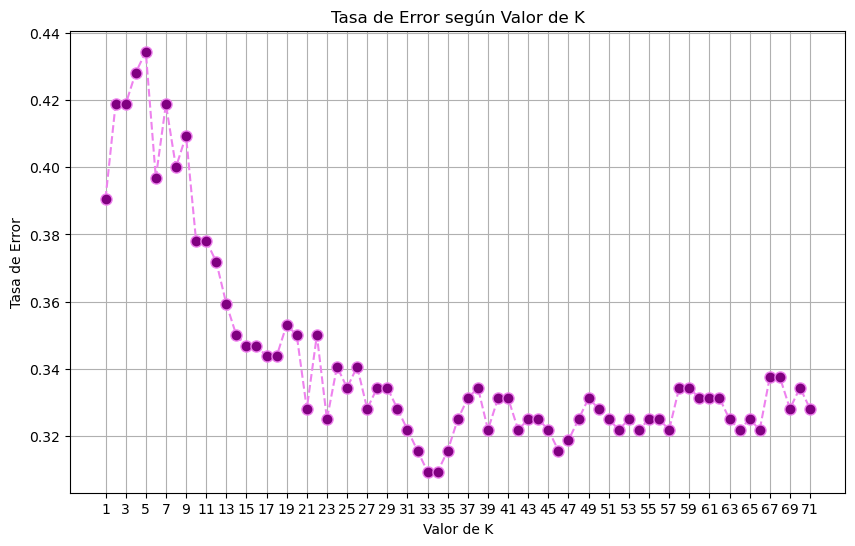

In [33]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, 72), error_rates, color='violet', linestyle='dashed', marker='o',
         markerfacecolor='purple', markersize=8)
plt.title('Tasa de Error según Valor de K')
plt.xlabel('Valor de K')
plt.ylabel('Tasa de Error')
plt.xticks(np.arange(1, 72, 2))
plt.grid(True)
plt.show()

In [34]:
optimal_k_index = np.argmin(error_rates)
optimal_k = range(1, 72)[optimal_k_index]
min_error = error_rates[optimal_k_index]

print(f"\nEl valor de K con la tasa de error más baja ({min_error:.4f}) es: {optimal_k}")

knn_optimal = KNeighborsClassifier(n_neighbors=optimal_k)
knn_optimal.fit(X_train_scaled, y_train)
y_pred_optimal = knn_optimal.predict(X_test_scaled)

print(f"\n--- Evaluación Final para K Óptimo = {optimal_k} ---")
print("Reporte de Clasificación Final KNN (vinos rojos):\n")
print(classification_report(y_test, y_pred_optimal))
report_dict = classification_report(
    y_test,
    y_pred_optimal,
    output_dict=True 
)

df_report = pd.DataFrame(report_dict).transpose()

nombre_archivo = "metricas_knn_vinos_rojos.xlsx"
df_report.to_excel(nombre_archivo, index=True)


El valor de K con la tasa de error más baja (0.3094) es: 33

--- Evaluación Final para K Óptimo = 33 ---
Reporte de Clasificación Final KNN (vinos rojos):

              precision    recall  f1-score   support

        Alta       0.46      0.38      0.42        34
        Baja       0.76      0.80      0.78       153
       Media       0.65      0.64      0.65       133

    accuracy                           0.69       320
   macro avg       0.63      0.61      0.62       320
weighted avg       0.68      0.69      0.69       320



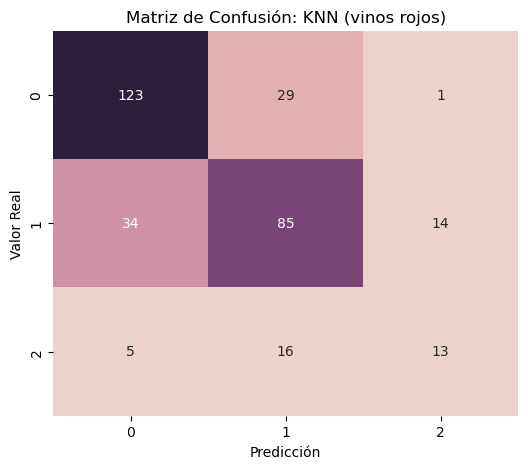


Clase 0:
 TP: 123
 TN: 128
 FP: 39
 FN: 30

Clase 1:
 TP: 85
 TN: 142
 FP: 45
 FN: 48

Clase 2:
 TP: 13
 TN: 271
 FP: 15
 FN: 21


In [35]:
labels = ['Baja', 'Media', 'Alta']
cm = confusion_matrix(y_test, y_pred_optimal, labels=labels)
default_cube = sns.cubehelix_palette(8) 
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap=default_cube, cbar=False)
plt.title('Matriz de Confusión: KNN (vinos rojos)')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.show()
classes = cm.shape[0]

tp = np.diag(cm)
fp = cm.sum(axis=0) - tp
fn = cm.sum(axis=1) - tp
tn = cm.sum() - (tp + fp + fn)

for i in range(classes):
    print(f"\nClase {i}:")
    print(" TP:", tp[i])
    print(" TN:", tn[i])
    print(" FP:", fp[i])
    print(" FN:", fn[i])